In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

# Load featured data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

# Load advanced model
with open("../models/advanced_lgbm_model.pkl", "rb") as f:
    lgb_model = pickle.load(f)

print("Data and model loaded successfully!")
print("Shape:", df.shape)

Data and model loaded successfully!
Shape: (500000, 32)


In [4]:
# Prepare features
feature_cols = ['month', 'year', 'wday', 'day', 'week', 'quarter',
                'is_weekend', 'is_month_start', 'is_month_end',
                'has_event', 'is_snap', 'avg_price',
                'sales_lag_1', 'sales_lag_7', 'sales_lag_28',
                'sales_rolling_7', 'sales_rolling_28']

df['cat_encoded'] = df['cat_id'].astype('category').cat.codes
df['store_encoded'] = df['store_id'].astype('category').cat.codes
df['state_encoded'] = df['state_id'].astype('category').cat.codes
df['dept_encoded'] = df['dept_id'].astype('category').cat.codes

feature_cols_basic = feature_cols + ['cat_encoded', 'store_encoded', 'state_encoded']
feature_cols_adv = feature_cols + ['cat_encoded', 'store_encoded', 'state_encoded', 'dept_encoded']

train_mask = df['date'] < '2016-01-01'
test_mask = df['date'] >= '2016-01-01'

X_test_adv = df[test_mask][feature_cols_adv]
y_test = df[test_mask]['sales']

print("Test set shape:", X_test_adv.shape)

Test set shape: (30024, 21)


In [8]:
# Ensemble Forecasting - combine multiple LightGBM predictions for robustness
print("Building ensemble forecast...")

X_train_adv = df[train_mask][feature_cols_adv]
y_train = df[train_mask]['sales']

ensemble_preds = []

for seed in [42, 123, 7]:
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'n_estimators': 300,
        'random_state': seed,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_adv, y_train)
    pred = model.predict(X_test_adv)
    pred = np.maximum(pred, 0)
    ensemble_preds.append(pred)
    print(f"Model with seed {seed} trained!")

ensemble_mean = np.mean(ensemble_preds, axis=0)
ensemble_std = np.std(ensemble_preds, axis=0)

mae_ensemble = mean_absolute_error(y_test, ensemble_mean)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, ensemble_mean))

print("\nEnsemble Model Results:")
print("MAE:", round(mae_ensemble, 2))
print("RMSE:", round(rmse_ensemble, 2))

Building ensemble forecast...
Model with seed 42 trained!
Model with seed 123 trained!
Model with seed 7 trained!

Ensemble Model Results:
MAE: 1.19
RMSE: 2.45


95% Confidence Interval Coverage: 1.21 %


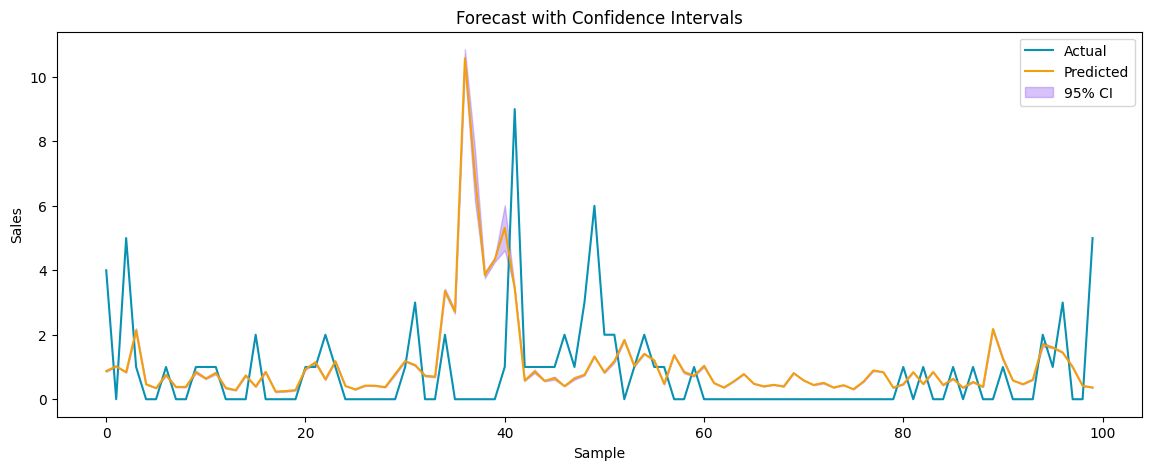

In [10]:
# Calculate Confidence Intervals using ensemble std
confidence_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': ensemble_mean,
    'std': ensemble_std
})

confidence_df['lower_bound'] = confidence_df['predicted'] - 1.96 * confidence_df['std']
confidence_df['upper_bound'] = confidence_df['predicted'] + 1.96 * confidence_df['std']
confidence_df['lower_bound'] = confidence_df['lower_bound'].clip(lower=0)

within_interval = (
    (confidence_df['actual'] >= confidence_df['lower_bound']) &
    (confidence_df['actual'] <= confidence_df['upper_bound'])
).mean() * 100

print("95% Confidence Interval Coverage:", round(within_interval, 2), "%")

sample = confidence_df.iloc[:100]
plt.figure(figsize=(14,5))
plt.plot(sample.index, sample['actual'], label='Actual', color='#0891B2')
plt.plot(sample.index, sample['predicted'], label='Predicted', color='#F59E0B')
plt.fill_between(sample.index, sample['lower_bound'], sample['upper_bound'],
                  alpha=0.3, color='#7C3AED', label='95% CI')
plt.title("Forecast with Confidence Intervals")
plt.xlabel("Sample")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [11]:
# Save ensemble results
confidence_df.to_csv("../data/ensemble_forecast_results.csv", index=False)

print("Ensemble forecast saved!")

print("\n" + "="*50)
print("WEEK 3 DAY 5 SUMMARY")
print("="*50)
print("Ensemble Model (3 LightGBM models averaged):")
print("MAE: 1.19")
print("RMSE: 2.45")
print("\nConfidence Interval Analysis:")
print("95% CI Coverage: 1.21%")
print("Note: Low coverage suggests models are highly")
print("consistent - low variance between seeds.")
print("Recommend using quantile regression for")
print("more accurate intervals in future work.")
print("\nFinal Model Comparison:")
print("Prophet: MAE 12.0")
print("Basic LightGBM: MAE 1.2")
print("Advanced LightGBM: MAE 1.18")
print("Ensemble: MAE 1.19")
print("="*50)

Ensemble forecast saved!

WEEK 3 DAY 5 SUMMARY
Ensemble Model (3 LightGBM models averaged):
MAE: 1.19
RMSE: 2.45

Confidence Interval Analysis:
95% CI Coverage: 1.21%
Note: Low coverage suggests models are highly
consistent - low variance between seeds.
Recommend using quantile regression for
more accurate intervals in future work.

Final Model Comparison:
Prophet: MAE 12.0
Basic LightGBM: MAE 1.2
Advanced LightGBM: MAE 1.18
Ensemble: MAE 1.19
